# Clasificación del valor de viviendas mediante características de ubicación y antigüedad

## Integrantes
- Vicente Alonso Fuentes Lagos  
- Marlon Gabriel Abreu Galviz

## Objetivo
Desarrollar una red neuronal artificial multicapa capaz de
clasificar viviendas según su rango de valor utilizando seis variables
relacionadas con ubicación, antigüedad y entorno.


#1. Primeros pasos

* **Librerías y semillas**

In [1]:
#Librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import SGD

#Semillas
np.random.seed(42)
tf.random.set_seed(42)

* **Carga de datos y corroboración**

In [2]:
df = pd.read_excel("Real_estate_valuation_USD.xlsx")
resumen = pd.DataFrame({
    "Variable": df.columns,
    "  Tipo de dato": df.dtypes.values,
    "  Valores nulos": df.isnull().sum().values
})

print(resumen.to_string())

                                 Variable   Tipo de dato    Valores nulos
0                                      No          int64                0
1                     X1 transaction date        float64                0
2                            X2 house age        float64                0
3  X3 distance to the nearest MRT station        float64                0
4         X4 number of convenience stores          int64                0
5                             X5 latitude        float64                0
6                            X6 longitude        float64                0
7              Y house price of unit area        float64                0


* **Eliminar columna innecesaria**

In [3]:
df = df.drop(columns=["No"])

print(df.columns)

Index(['X1 transaction date', 'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area'],
      dtype='object')


* **Explicación de cada variable:**


1.   **X1 transaction date:** Fecha en que se realizó la transacción.
2.   **X2 house age:** Antigüedad de la vivienda.
3.   **X3 distance to the nearest MRT station:** Es la distancia desde la vivienda hasta la estación de metro más cercana.
4.   **X4 number of convenience stores:** Es la cantidad de tiendas cercanas.
5.   **X5 latitude:** Es la latitud geográfica de la vivienda, medida en grados.
6.   **X6 longitude:** Es la longitud geográfica de la vivienda, también medida en grados.
7.   **Y house price of unit area:** Precio por unidad de área, el valor monetario que originalmente se quiere predecir.



#2. Gráficos

* **¿Cómo se distribuyen los precios de las viviendas?**

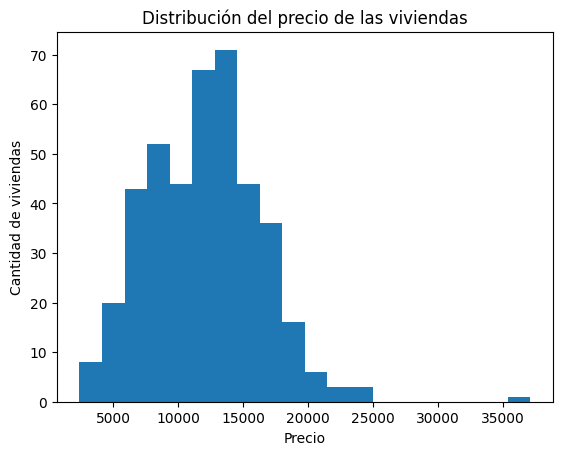

In [4]:
plt.hist(df["Y house price of unit area"], bins=20)
plt.xlabel("Precio")
plt.ylabel("Cantidad de viviendas")
plt.title("Distribución del precio de las viviendas")
plt.show()

La mayor parte de las viviendas se concentra en valores aproximados entre 7.000 y 18.000 USD por Ping, siendo más frecuentes los precios cercanos a 12.000–15.000 USD. También se observa un valor muy alto cercano a 37.000 USD, que se aleja bastante del resto de los datos.

* **¿Las casas más antiguas son más caras?**

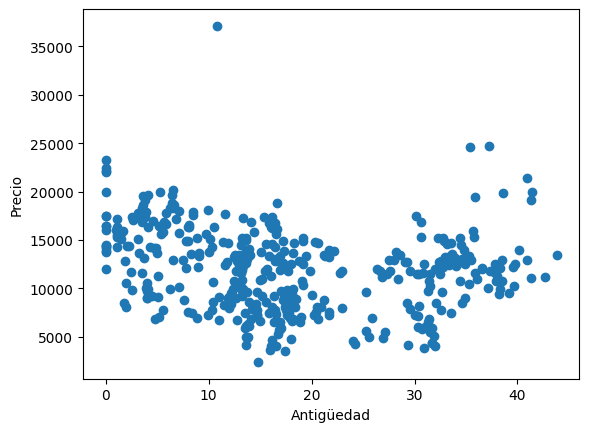

In [5]:
plt.scatter(
    df["X2 house age"],
    df["Y house price of unit area"]
)
plt.xlabel("Antigüedad")
plt.ylabel("Precio")
plt.show()

El gráfico muestra que no existe una relación completamente lineal entre la antigüedad y el precio. Sin embargo, se puede observar que muchas viviendas de menor antigüedad presentan precios más altos, mientras que entre aproximadamente 15 y 30 años aparecen con mayor frecuencia precios más bajos. Aun así, existen excepciones, por lo que la antigüedad por sí sola no permite explicar el precio.

* **¿Influye la cercanía al metro con el precio de la vivienda?**

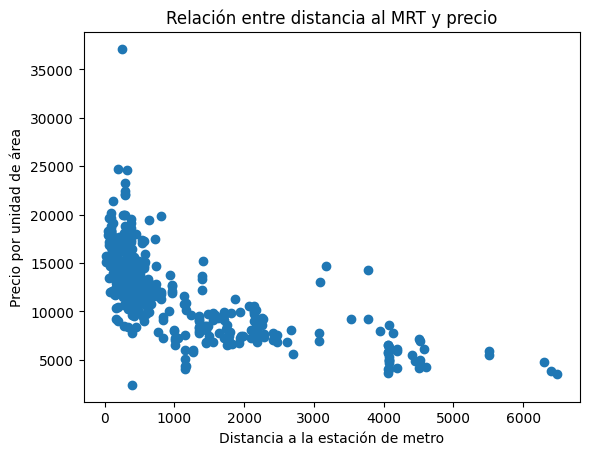

In [53]:
plt.scatter(
    df["X3 distance to the nearest MRT station"],
    df["Y house price of unit area"]
)

plt.xlabel("Distancia a la estación de metro")
plt.ylabel("Precio por unidad de área")
plt.title("Relación entre distancia al MRT y precio")

plt.show()

Se observa una relación bastante clara entre la distancia a la estación MRT y el precio. Las viviendas ubicadas más cerca de una estación tienden a presentar precios más altos, mientras que a medida que aumenta la distancia los precios generalmente disminuyen. Esto indica que la cercanía al transporte público puede ser una característica relevante para el modelo.

* **Relación entre tiendas cercanas y precio**



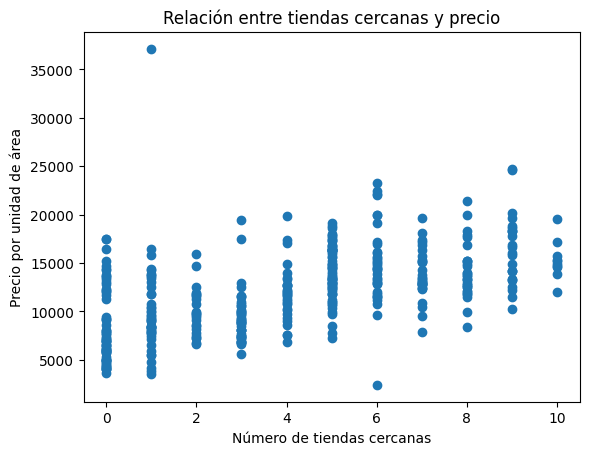

In [52]:
plt.scatter(
    df["X4 number of convenience stores"],
    df["Y house price of unit area"]
)

plt.xlabel("Número de tiendas cercanas")
plt.ylabel("Precio por unidad de área")
plt.title("Relación entre tiendas cercanas y precio")

plt.show()

El gráfico muestra una tendencia general en la que las viviendas con mayor cantidad de tiendas cercanas presentan precios más altos. Las viviendas con pocas tiendas concentran una mayor cantidad de valores bajos, mientras que al aumentar el número de tiendas aparecen con mayor frecuencia precios elevados. Esto sugiere que el acceso a servicios cercanos puede influir en el valor de una vivienda.

**Conclusión de la exploración gráfica**

La exploración inicial muestra que algunas variables presentan una relación más clara con el precio que otras. La distancia a la estación MRT y la cantidad de tiendas cercanas parecen tener una influencia importante, mientras que la antigüedad presenta una relación menos directa. Estos resultados justifican el uso conjunto de varias características para entrenar el modelo de clasificación.

#3. Preparar variable y datos

* **Clasificar los precios**

Bajo  → 0

Medio → 1

Alto  → 2

In [8]:
df["categoria_precio"],limites = pd.qcut(df["Y house price of unit area"],
    q=3,
    labels=[0, 1, 2],
    retbins=True
)

print("Cantidad de viviendas por categoría:")
print(df["categoria_precio"].value_counts().sort_index())

print("\nLímites utilizados:")
print(limites)

Cantidad de viviendas por categoría:
categoria_precio
0    141
1    136
2    137
Name: count, dtype: int64

Límites utilizados:
[ 2401.2124  9889.2037 13617.4019 37124.0075]


* **Conversión del precio a categorías**

La variable original de precio es numérica y continua, pero el problema de esta evaluación es de clasificación. Por este motivo se utiliza **qcut** para dividir los precios en tres categorías: Bajo, Medio y Alto.

Se utilizan tres grupos con cantidades similares de viviendas para evitar que una categoría tenga muchos más datos que las otras. Finalmente, las categorías se representan como 0, 1 y 2 para poder utilizarlas durante el entrenamiento de la red neuronal.

* **Definir X e Y**

  En X entraran seis variables

  En Y saldrá la clasificación del precio ( Lo que intentamos predecir)

In [9]:
X = df[[
    "X1 transaction date",
    "X2 house age",
    "X3 distance to the nearest MRT station",
    "X4 number of convenience stores",
    "X5 latitude",
    "X6 longitude"
]]

y = df["categoria_precio"].astype(int)

* **Separar entrenamiento y prueba**

Seguiremos la proporción de 80% (331 datos) entrenamiento y 20% (83 datos) prueba para los datos

Test: Datos de prueba

Train: Datos de entrenamiento

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

* **Estandarizar variables**

Las 6 variables tienen escalas muy distintas. Esto ayuda a que la red aprenda de forma más estable.

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Creación de modelo MLP

* **Crear modelo base**

  *   6 Entradas: Variables de las columnas.
  *   16 Neuronas: Primera capa de neuronas.
  *   8 Neuronas: Segunda capa de neuronas.
  *   3 Salidas: Clasificación de los precios.



* **Justificación de la arquitectura y funciones utilizadas**

El modelo recibe 6 variables de entrada, correspondientes a las características utilizadas para describir cada vivienda.

Se utilizan dos capas ocultas de 16 y 8 neuronas con función de activación ReLU. ReLU permite que la red aprenda relaciones no lineales entre las variables y posteriormente se comprobará mediante experimentos si esta arquitectura es adecuada.

La capa de salida tiene 3 neuronas porque existen tres categorías posibles: Bajo, Medio y Alto. Se utiliza Softmax para transformar la salida de la red en probabilidades para cada categoría.

Como las categorías están representadas directamente con los números 0, 1 y 2, se utiliza Sparse Categorical Crossentropy como función de pérdida.

Para actualizar los pesos se utiliza SGD con un learning rate inicial de 0,01. Estos valores serán posteriormente evaluados mediante experimentos.

In [12]:
modelo_base = Sequential([
    Dense(16, activation="relu", input_shape=(6,)),
    Dense(8, activation="relu"),
    Dense(3, activation="softmax")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


* **Configurar SGD**

SGD modifica los pesos de la red para intentar disminuir el error.

In [13]:
optimizador = SGD(learning_rate=0.01)

In [14]:
modelo_base.compile(
    optimizer=optimizador,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


#5. Entrenamiento y análisis

* **Entrenar modelo base**



In [15]:
history_base = modelo_base.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=16,
    verbose=0
)

* **Gráfico de pérdida**

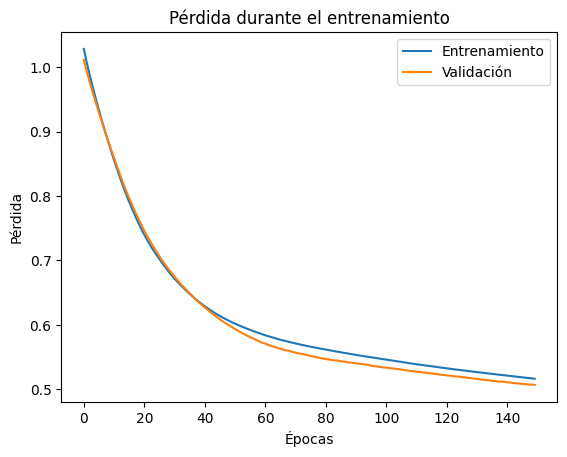

In [48]:
plt.plot(history_base.history["loss"], label="Entrenamiento")
plt.plot(history_base.history["val_loss"], label="Validación")

plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.title("Pérdida durante el entrenamiento")

plt.legend()
plt.show()

 La pérdida disminuye durante el entrenamiento, por lo que el modelo está aprendiendo. La diferencia con validación muestra una leve señal de sobreajuste.

* **Gráfico de accuracy**

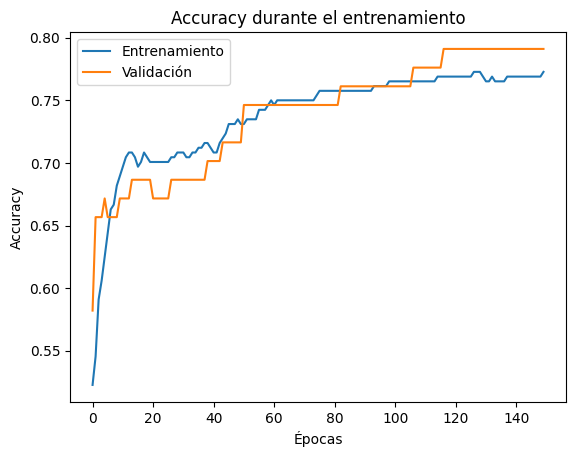

In [49]:
plt.plot(history_base.history["accuracy"], label="Entrenamiento")
plt.plot(history_base.history["val_accuracy"], label="Validación")

plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.title("Accuracy durante el entrenamiento")

plt.legend()
plt.show()

El Accuracy de entrenamiento aumenta hasta cerca del 83 %, mientras que el de validación se mantiene entre 76 % y 79 %. Esto indica que el modelo aprende, pero puede mejorar su generalización.

* **Mapa de calor de los pesos aprendidos en la primera capa**

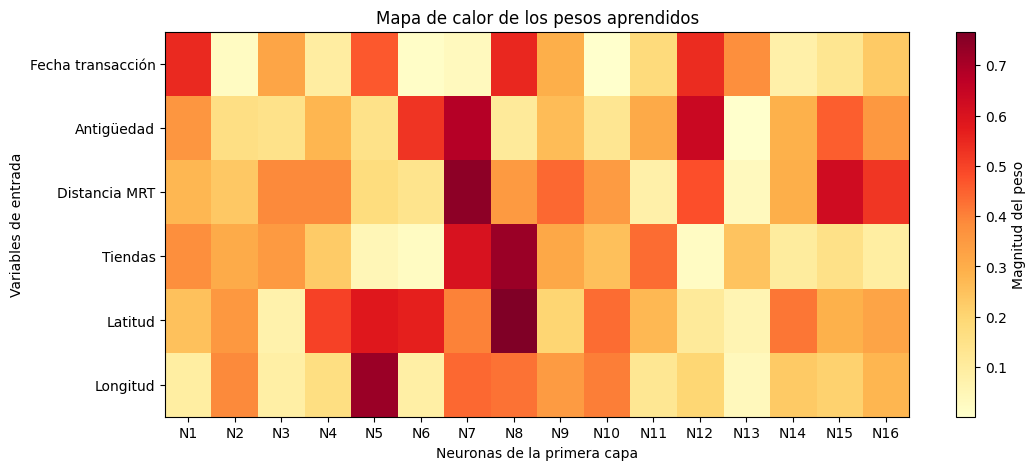

In [50]:
pesos_primera_capa = modelo_base.layers[0].get_weights()[0]

variables = [
    "Fecha transacción",
    "Antigüedad",
    "Distancia MRT",
    "Tiendas",
    "Latitud",
    "Longitud"
]

plt.figure(figsize=(12, 5))

plt.imshow(
    np.abs(pesos_primera_capa),
    aspect="auto",
    cmap="YlOrRd"
)

plt.xticks(
    range(16),
    [f"N{i+1}" for i in range(16)]
)

plt.yticks(
    range(6),
    variables
)

plt.xlabel("Neuronas de la primera capa")
plt.ylabel("Variables de entrada")
plt.title("Mapa de calor de los pesos aprendidos")

plt.colorbar(label="Magnitud del peso")

plt.show()

El mapa de calor muestra la magnitud de los pesos aprendidos entre las variables de entrada y las neuronas de la primera capa. Los valores más intensos representan conexiones con pesos de mayor magnitud después del entrenamiento.

Este gráfico permite observar cómo la red ajustó sus conexiones durante el aprendizaje. Sin embargo, estos valores no deben interpretarse directamente como la importancia individual de cada variable.

#6. Evaluación del modelo base

* **Predicciones**

Esto puede devolver una predicción en el resultado para una vivienda.

In [18]:
y_prob_base = modelo_base.predict(X_test_scaled)
y_pred_base = np.argmax(y_prob_base, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


* **Métricas**

In [20]:
accuracy_base = accuracy_score(y_test, y_pred_base)

precision_base = precision_score(
    y_test,
    y_pred_base,
    average="weighted"
)

recall_base = recall_score(
    y_test,
    y_pred_base,
    average="weighted"
)

f1_base = f1_score(
    y_test,
    y_pred_base,
    average="weighted"
)

print("Accuracy:", accuracy_base)
print("Precision:", precision_base)
print("Recall:", recall_base)
print("F1-Score:", f1_base)

Accuracy: 0.7831325301204819
Precision: 0.7853753018896352
Recall: 0.7831325301204819
F1-Score: 0.783714549852787


El modelo base obtuvo resultados cercanos al 78 % en Accuracy, Precision, Recall y F1-Score. Esto muestra un rendimiento bastante equilibrado en las métricas evaluadas.

* **Resumen de métricas del modelo base**

In [34]:
tabla_metricas = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Resultado": [
        accuracy_base,
        precision_base,
        recall_base,
        f1_base
    ]
})

tabla_metricas

,Métrica,Resultado
0,Accuracy,0.783133
1,Precision,0.785375
2,Recall,0.783133
3,F1-Score,0.783715


* **Reporte de clasificación**

In [21]:
print(
    classification_report(
        y_test,
        y_pred_base,
        target_names=["Bajo", "Medio", "Alto"]
    )
)

              precision    recall  f1-score   support

        Bajo       0.83      0.86      0.84        28
       Medio       0.68      0.70      0.69        27
        Alto       0.85      0.79      0.81        28

    accuracy                           0.78        83
   macro avg       0.78      0.78      0.78        83
weighted avg       0.79      0.78      0.78        83



La clase Bajo obtuvo el mayor F1-Score con 0,84, seguida de Alto con 0,81. La clase Medio obtuvo un F1-Score de 0,69, por lo que sigue siendo la categoría que más le cuesta clasificar al modelo. En general, el modelo alcanzó un Accuracy cercano al 78 %.

* **Matriz de confusión**

La matriz de confusión permite observar cuántas viviendas fueron clasificadas
correctamente y en qué categorías se producen más errores.

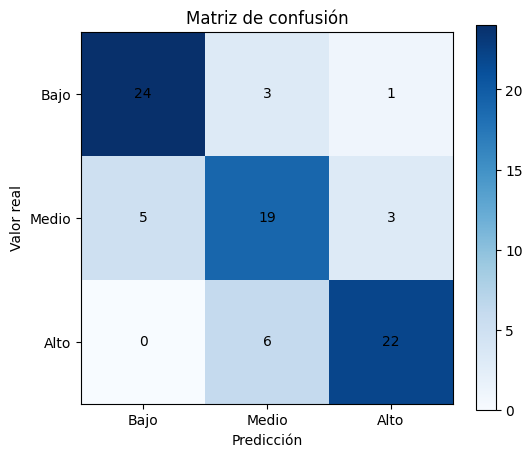

In [51]:
matriz_confusion = confusion_matrix(
    y_test,
    y_pred_base
)

plt.figure(figsize=(6, 5))
plt.imshow(matriz_confusion, cmap="Blues")

plt.xticks(
    [0, 1, 2],
    ["Bajo", "Medio", "Alto"]
)

plt.yticks(
    [0, 1, 2],
    ["Bajo", "Medio", "Alto"]
)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión")

for i in range(3):
    for j in range(3):
        plt.text(
            j,
            i,
            matriz_confusion[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

La matriz muestra que el modelo clasifica mejor las viviendas de precio Bajo, con 24 aciertos. La categoría Alto obtuvo 22 aciertos, mientras que Medio obtuvo 19 de 27 casos. Esto confirma que la categoría Medio sigue siendo la más difícil de identificar.

#7. Experimentos y ajuste de hiperparámetros

* **Experimento 1: ¿Entrenar más tiempo mejora el modelo?**

Se comparan 50, 100 y 150 épocas para observar si aumentar el tiempo de entrenamiento mejora el modelo.

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,Épocas,Validation Accuracy,Validation Loss
0,50,0.716418,0.571163
1,100,0.761194,0.558024
2,150,0.746269,0.537874


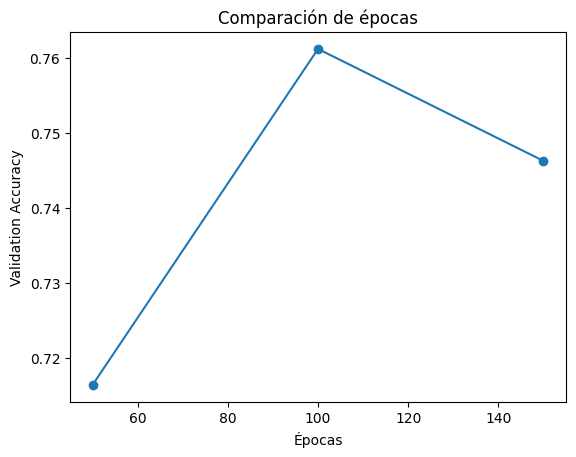

In [54]:
#Experimento
resultados_epocas = []

for epocas in [50, 100, 150]:

    tf.random.set_seed(42)

    modelo = Sequential([
        Dense(16, activation="relu", input_shape=(6,)),
        Dense(8, activation="relu"),
        Dense(3, activation="softmax")
    ])

    modelo.compile(
        optimizer=SGD(learning_rate=0.01),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    historia = modelo.fit(
        X_train_scaled,
        y_train,
        validation_split=0.2,
        epochs=epocas,
        batch_size=16,
        verbose=0
    )

    resultados_epocas.append([
        epocas,
        historia.history["val_accuracy"][-1],
        historia.history["val_loss"][-1]
    ])

#Tabla
tabla_epocas = pd.DataFrame(
  resultados_epocas,
  columns=[
      "Épocas",
      "Validation Accuracy",
      "Validation Loss"
  ]
)

display(tabla_epocas)


plt.plot(
    tabla_epocas["Épocas"],
    tabla_epocas["Validation Accuracy"],
    marker="o"
)

plt.xlabel("Épocas")
plt.ylabel("Validation Accuracy")
plt.title("Comparación de épocas")

plt.show()


Con 150 épocas se obtuvo el mayor Accuracy de validación entre las configuraciones probadas. Por este motivo se mantiene esta cantidad de épocas para el modelo.

* **Experimento 2: ¿Cambiar la velocidad de aprendizaje mejora el entrenamiento?**

Se prueban tasas de aprendizaje de 0,001, 0,01 y 0,1 para analizar cómo influye la velocidad con la que SGD actualiza los pesos del modelo.

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,Learning Rate,Validation Accuracy,Validation Loss
0,0.001,0.776119,0.824703
1,0.010,0.791045,0.483382
2,0.100,0.805970,0.527131


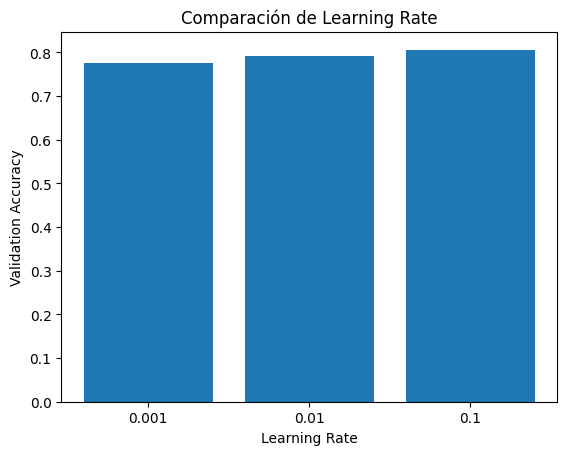

In [44]:
resultados_lr = []

for lr in [0.001, 0.01, 0.1]:

    tf.random.set_seed(42)

    modelo = Sequential([
        Dense(16, activation="relu", input_shape=(6,)),
        Dense(8, activation="relu"),
        Dense(3, activation="softmax")
    ])

    modelo.compile(
        optimizer=SGD(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    historia = modelo.fit(
        X_train_scaled,
        y_train,
        validation_split=0.2,
        epochs=150,
        batch_size=16,
        verbose=0
    )

    resultados_lr.append([
        lr,
        historia.history["val_accuracy"][-1],
        historia.history["val_loss"][-1]
    ])

tabla_lr = pd.DataFrame(
    resultados_lr,
    columns=[
        "Learning Rate",
        "Validation Accuracy",
        "Validation Loss"
    ]
)

display(tabla_lr)


plt.bar(
    tabla_lr["Learning Rate"].astype(str),
    tabla_lr["Validation Accuracy"]
)

plt.xlabel("Learning Rate")
plt.ylabel("Validation Accuracy")
plt.title("Comparación de Learning Rate")

plt.show()

El learning rate de 0,1 obtuvo el mayor Accuracy de validación. Sin embargo, 0,01 obtuvo un resultado cercano y presentó una pérdida menor, por lo que se mantiene este valor como configuración del modelo.

* **Experimento 3: ¿Cambiar la cantidad de datos procesados por actualización ayuda?**

Se comparan batch de 8, 16 y 32 para observar cómo influye la cantidad de registros procesados antes de actualizar los pesos de la red.

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,Batch Size,Validation Accuracy,Validation Loss
0,8,0.805970,0.486119
1,16,0.805970,0.523791
2,32,0.746269,0.581342


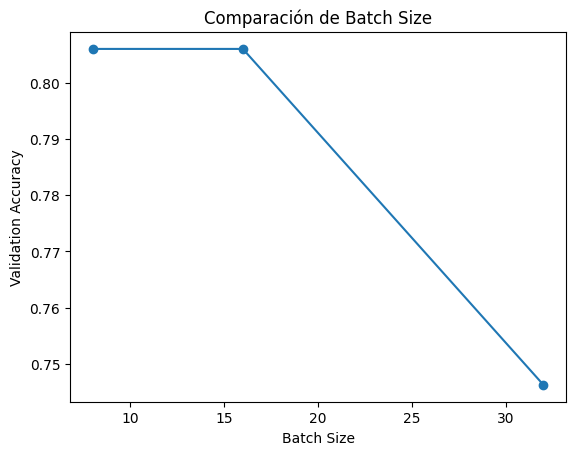

In [45]:
resultados_batch = []

for batch in [8, 16, 32]:

    tf.random.set_seed(42)

    modelo = Sequential([
        Dense(16, activation="relu", input_shape=(6,)),
        Dense(8, activation="relu"),
        Dense(3, activation="softmax")
    ])

    modelo.compile(
        optimizer=SGD(learning_rate=0.01),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    historia = modelo.fit(
        X_train_scaled,
        y_train,
        validation_split=0.2,
        epochs=150,
        batch_size=batch,
        verbose=0
    )

    resultados_batch.append([
        batch,
        historia.history["val_accuracy"][-1],
        historia.history["val_loss"][-1]
    ])

tabla_batch = pd.DataFrame(
    resultados_batch,
    columns=[
        "Batch Size",
        "Validation Accuracy",
        "Validation Loss"
    ]
)

display(tabla_batch)


plt.plot(
    tabla_batch["Batch Size"],
    tabla_batch["Validation Accuracy"],
    marker="o"
)

plt.xlabel("Batch Size")
plt.ylabel("Validation Accuracy")
plt.title("Comparación de Batch Size")

plt.show()

Los batch de 8 y 16 obtuvieron el mismo Accuracy de validación y ambos superaron a batch 32. Se mantiene batch 16 como configuración del modelo, ya que presentó un buen rendimiento durante las pruebas realizadas.

* **Experimento 4: ¿ReLU o Sigmoid funciona mejor?**

Se comparan ReLU y Sigmoid en las capas ocultas para observar cuál permite obtener mejores resultados de Accuracy y pérdida.

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,Activación,Validation Accuracy,Validation Loss
0,relu,0.746269,0.567986
1,sigmoid,0.552239,0.882856


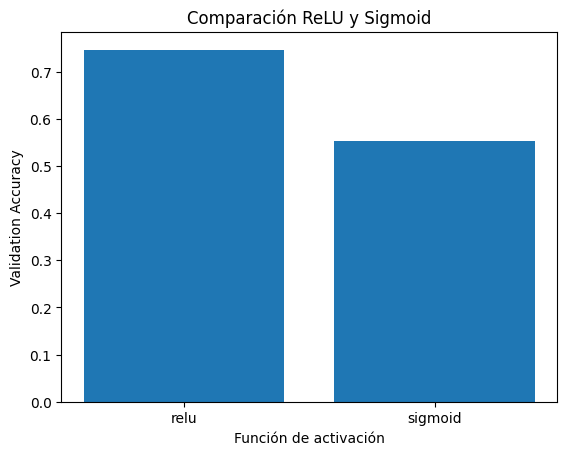

In [46]:
resultados_activacion = []

for activacion in ["relu", "sigmoid"]:

    tf.random.set_seed(42)

    modelo = Sequential([
        Dense(16, activation=activacion, input_shape=(6,)),
        Dense(8, activation=activacion),
        Dense(3, activation="softmax")
    ])

    modelo.compile(
        optimizer=SGD(learning_rate=0.01),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    historia = modelo.fit(
        X_train_scaled,
        y_train,
        validation_split=0.2,
        epochs=150,
        batch_size=16,
        verbose=0
    )

    resultados_activacion.append([
        activacion,
        historia.history["val_accuracy"][-1],
        historia.history["val_loss"][-1]
    ])

tabla_activacion = pd.DataFrame(
    resultados_activacion,
    columns=[
        "Activación",
        "Validation Accuracy",
        "Validation Loss"
    ]
)

display(tabla_activacion)

plt.bar(
    tabla_activacion["Activación"],
    tabla_activacion["Validation Accuracy"]
)

plt.xlabel("Función de activación")
plt.ylabel("Validation Accuracy")
plt.title("Comparación ReLU y Sigmoid")

plt.show()

ReLU obtuvo un mejor Accuracy de validación y una menor pérdida que Sigmoid. Por este motivo se mantiene ReLU como función de activación para las capas ocultas.

* **Experimento 5: ¿Necesitamos realmente dos capas ocultas?**

Se compara una arquitectura con una capa oculta de 16 neuronas frente a otra con dos capas ocultas de 16 y 8 neuronas.

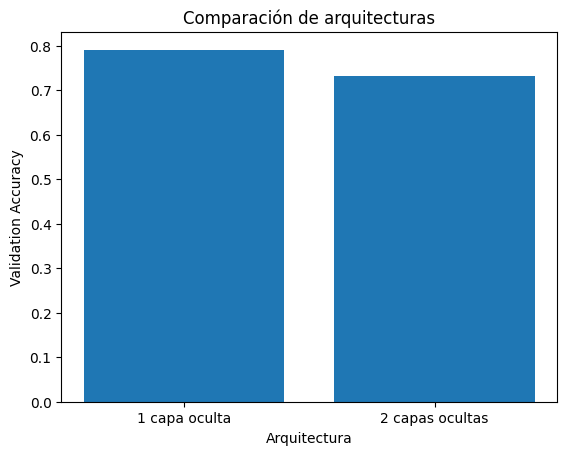

In [39]:
#Una capa oculta

modelo_1_capa = Sequential([
    Dense(16, activation="relu", input_shape=(6,)),
    Dense(3, activation="softmax")
])

modelo_1_capa.compile(
    optimizer=SGD(learning_rate=0.01),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

historia_1_capa = modelo_1_capa.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=16,
    verbose=0
)

#Dos capas ocultas

modelo_2_capas = Sequential([
    Dense(16, activation="relu", input_shape=(6,)),
    Dense(8, activation="relu"),
    Dense(3, activation="softmax")
])

modelo_2_capas.compile(
    optimizer=SGD(learning_rate=0.01),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

historia_2_capas = modelo_2_capas.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=16,
    verbose=0
)

tabla_capas = pd.DataFrame({
    "Arquitectura": [
        "1 capa oculta",
        "2 capas ocultas"
    ],
    "Validation Accuracy": [
        historia_1_capa.history["val_accuracy"][-1],
        historia_2_capas.history["val_accuracy"][-1]
    ],
    "Validation Loss": [
        historia_1_capa.history["val_loss"][-1],
        historia_2_capas.history["val_loss"][-1]
    ]
})

display(tabla_capas)

plt.bar(
    tabla_capas["Arquitectura"],
    tabla_capas["Validation Accuracy"]
)

plt.xlabel("Arquitectura")
plt.ylabel("Validation Accuracy")
plt.title("Comparación de arquitecturas")

plt.show()

Con una capa oculta el Accuracy fue 73,13 %, mientras que con dos capas subió a 79,10 % y además bajó la pérdida. Por eso se mantienen dos capas ocultas.

* **Experimento 6: ¿Ayuda a disminuir el sobreajuste?**

Se comparará el modelo sin Dropout con otro que utilice Dropout para analizar si esta técnica ayuda a reducir el sobreajuste y mejorar la validación.

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,Modelo,Validation Accuracy,Validation Loss
0,Sin Dropout,0.791045,0.496803
1,Con Dropout,0.761194,0.526861


------------------------------------------------


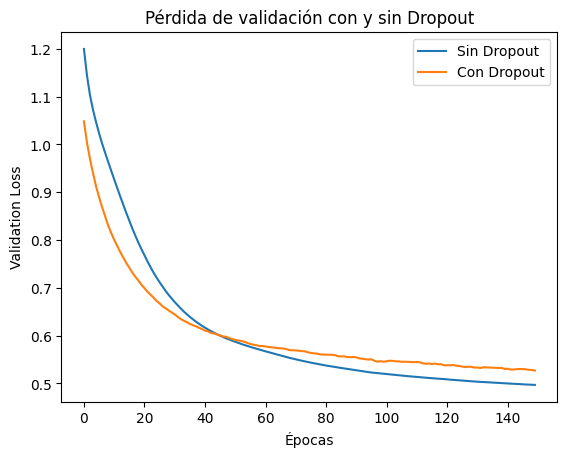

------------------------------------------------


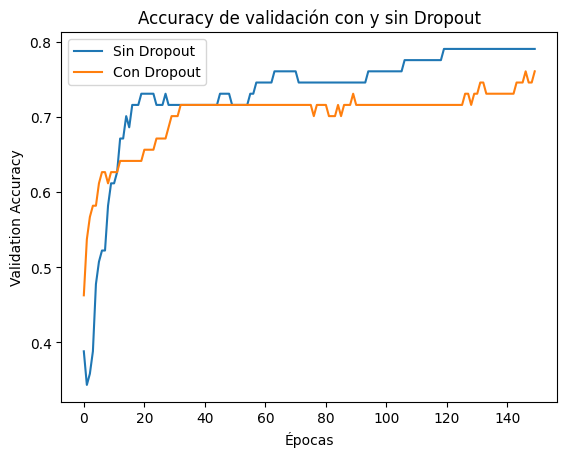

------------------------------------------------


In [28]:
# Modelo sin dropout
tf.random.set_seed(42)

modelo_sin_dropout = Sequential([
    Dense(16, activation="relu", input_shape=(6,)),
    Dense(8, activation="relu"),
    Dense(3, activation="softmax")
])

modelo_sin_dropout.compile(
    optimizer=SGD(learning_rate=0.01),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

historia_sin_dropout = modelo_sin_dropout.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=16,
    verbose=0
)

#Modelo con dropout
tf.random.set_seed(42)

modelo_con_dropout = Sequential([
    Dense(16, activation="relu", input_shape=(6,)),
    Dropout(0.2),
    Dense(8, activation="relu"),
    Dense(3, activation="softmax")
])

modelo_con_dropout.compile(
    optimizer=SGD(learning_rate=0.01),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

historia_con_dropout = modelo_con_dropout.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=16,
    verbose=0
)

#Tabla comparativa

tabla_dropout = pd.DataFrame({
    "Modelo": [
        "Sin Dropout",
        "Con Dropout"
    ],
    "Validation Accuracy": [
        historia_sin_dropout.history["val_accuracy"][-1],
        historia_con_dropout.history["val_accuracy"][-1]
    ],
    "Validation Loss": [
        historia_sin_dropout.history["val_loss"][-1],
        historia_con_dropout.history["val_loss"][-1]
    ]
})

display(tabla_dropout)
print("------------------------------------------------")

#Comparar pérdida
plt.plot(
    historia_sin_dropout.history["val_loss"],
    label="Sin Dropout"
)

plt.plot(
    historia_con_dropout.history["val_loss"],
    label="Con Dropout"
)

plt.xlabel("Épocas")
plt.ylabel("Validation Loss")
plt.title("Pérdida de validación con y sin Dropout")

plt.legend()
plt.show()
print("------------------------------------------------")

#Comparar accuaracy
plt.plot(
    historia_sin_dropout.history["val_accuracy"],
    label="Sin Dropout"
)

plt.plot(
    historia_con_dropout.history["val_accuracy"],
    label="Con Dropout"
)

plt.xlabel("Épocas")
plt.ylabel("Validation Accuracy")
plt.title("Accuracy de validación con y sin Dropout")

plt.legend()
plt.show()
print("------------------------------------------------")

El modelo sin Dropout obtuvo un Accuracy mayor y una pérdida menor que el modelo con Dropout. Por este motivo, en esta comparación no se observa una mejora al utilizar Dropout y se decide mantener el modelo sin esta técnica.

* **Experimento 7: ¿Qué función de pérdida funciona mejor para este problema?**

Se compara Sparse Categorical Crossentropy con Mean Squared Error (MSE),
manteniendo la misma arquitectura y los mismos hiperparámetros

In [29]:
# Preparar etiquetas one-hot únicamente para el modelo con MSE
y_train_mse = tf.keras.utils.to_categorical(
    y_train,
    num_classes=3
)

resultados_perdida = []


# Sparse Categorical Crossentropy


tf.random.set_seed(42)

modelo_sparse = Sequential([
    Dense(16, activation="relu", input_shape=(6,)),
    Dense(8, activation="relu"),
    Dense(3, activation="softmax")
])

modelo_sparse.compile(
    optimizer=SGD(learning_rate=0.01),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

historia_sparse = modelo_sparse.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=16,
    verbose=0
)

resultados_perdida.append([
    "Sparse Categorical Crossentropy",
    historia_sparse.history["val_accuracy"][-1],
    historia_sparse.history["val_loss"][-1]
])



# Mean Squared Error


tf.random.set_seed(42)

modelo_mse = Sequential([
    Dense(16, activation="relu", input_shape=(6,)),
    Dense(8, activation="relu"),
    Dense(3, activation="softmax")
])

modelo_mse.compile(
    optimizer=SGD(learning_rate=0.01),
    loss="mean_squared_error",
    metrics=["accuracy"]
)

historia_mse = modelo_mse.fit(
    X_train_scaled,
    y_train_mse,
    validation_split=0.2,
    epochs=150,
    batch_size=16,
    verbose=0
)

resultados_perdida.append([
    "Mean Squared Error",
    historia_mse.history["val_accuracy"][-1],
    historia_mse.history["val_loss"][-1]
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,Función de pérdida,Validation Accuracy,Validation Loss
0,Sparse Categorical Crossentropy,0.805970,0.477096
1,Mean Squared Error,0.701493,0.115246


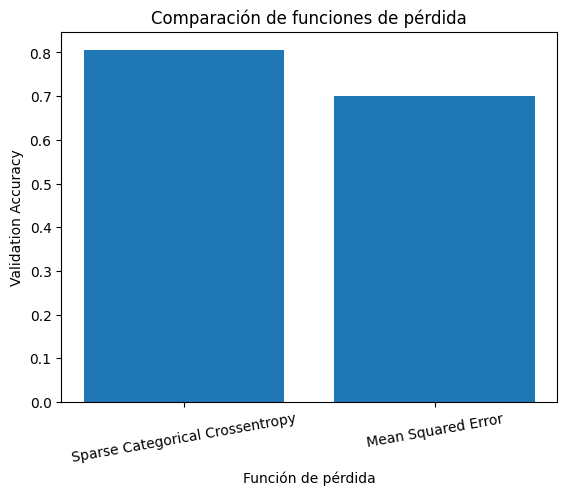

In [47]:
tabla_perdida = pd.DataFrame(
    resultados_perdida,
    columns=[
        "Función de pérdida",
        "Validation Accuracy",
        "Validation Loss"
    ]
)

display(tabla_perdida)

plt.bar(
    tabla_perdida["Función de pérdida"],
    tabla_perdida["Validation Accuracy"]
)

plt.xlabel("Función de pérdida")
plt.ylabel("Validation Accuracy")
plt.title("Comparación de funciones de pérdida")

plt.xticks(rotation=10)

plt.show()

Sparse Categorical Crossentropy obtuvo un mejor Accuracy de validación que Mean Squared Error. Además, se mantiene esta función de pérdida porque está diseñada para problemas de clasificación con varias clases, como Bajo, Medio y Alto. Los valores de pérdida de ambas funciones no se comparan directamente porque calculan el error de forma diferente.

#8. Selección de configuración final

A partir de los experimentos realizados se observó que varias configuraciones utilizadas inicialmente en el modelo base presentaron buenos resultados. Se seleccionan 150 épocas, learning rate de 0,01, batch size de 16, activación ReLU y una arquitectura de dos capas ocultas de 16 y 8 neuronas. En el caso de Dropout, no se observó una mejora clara, por lo que no se incorpora a la configuración seleccionada.
Debido a que esta configuración coincide en gran parte con el modelo base ya entrenado y evaluado, no es necesario volver a entrenar una red idéntica. El modelo base, con un Accuracy aproximado de 78,31 %, se mantiene como el modelo seleccionado.

In [41]:
tabla_configuracion_final = pd.DataFrame({
    "Parámetro": [
        "Épocas",
        "Learning Rate",
        "Batch Size",
        "Activación",
        "Primera capa oculta",
        "Segunda capa oculta",
        "Función de salida",
        "Función de pérdida",
        "Optimizador",
        "Dropout"
    ],
    "Valor seleccionado": [
        150,
        0.01,
        16,
        "ReLU",
        "16 neuronas",
        "8 neuronas",
        "Softmax",
        "Sparse Categorical Crossentropy",
        "SGD",
        "No"
    ]
})

tabla_configuracion_final

,Parámetro,Valor seleccionado
0,Épocas,150
1,Learning Rate,0.01
2,Batch Size,16
3,Activación,ReLU
4,Primera capa oculta,16 neuronas
5,Segunda capa oculta,8 neuronas
6,Función de salida,Softmax
7,Función de pérdida,Sparse Categorical Crossentropy
8,Optimizador,SGD
9,Dropout,No


#9. Prueba con una vivienda nueva


In [32]:
#Ingreso de datos de pruebas
nueva_vivienda = pd.DataFrame([[
    2013.5,
    10,
    500,
    6,
    24.98,
    121.54
]], columns=[
    "X1 transaction date",
    "X2 house age",
    "X3 distance to the nearest MRT station",
    "X4 number of convenience stores",
    "X5 latitude",
    "X6 longitude"
])

nueva_vivienda_scaled = scaler.transform(nueva_vivienda)

#Predicción
probabilidades = modelo_base.predict(nueva_vivienda_scaled)

clase = np.argmax(probabilidades, axis=1)[0]

categorias = {
    0: "Bajo",
    1: "Medio",
    2: "Alto"
}

print("Clasificación:", categorias[clase])

print("Probabilidades:", probabilidades)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Clasificación: Alto
Probabilidades: [[0.0021191  0.16435933 0.8335216 ]]


Para la vivienda de prueba, el modelo predijo la categoría Alto con una probabilidad aproximada de 83,35 %. La categoría Medio obtuvo cerca de 16,44 %, mientras que la probabilidad de pertenecer a Bajo fue de aproximadamente 0,21 %.

## Posibles mejoras

A partir de las métricas obtenidas se observó que la categoría Medio es la más difícil de clasificar. Como mejora futura se podrían incorporar más datos, especialmente viviendas cercanas a los límites entre las categorías, y probar nuevas combinaciones de hiperparámetros. Esto podría ayudar al modelo a diferenciar mejor los casos que actualmente generan más confusión.

#10. Conclusión

En este trabajo se desarrolló una red neuronal MLP para clasificar viviendas en las categorías Bajo, Medio y Alto. Durante el proceso se probaron distintas configuraciones para ver cómo influían en el rendimiento del modelo, como las épocas, el learning rate, el batch size, las funciones de activación, la arquitectura y el Dropout. Finalmente, el modelo obtuvo un Accuracy cercano al 80 %, mostrando un buen resultado para este problema. También se observó que la categoría Medio fue la más difícil de clasificar, mientras que Bajo y Alto tuvieron mejores resultados.